# Explorando os dados


In [1]:
import pandas as pd

In [2]:
# 1. Carregar os dados (Ajuste os nomes dos arquivos conforme sua pasta)
df_imu = pd.read_csv('../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data.csv')
df_rc = pd.read_csv('../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-rc-out.csv')


In [3]:
target = pd.read_csv('../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-setpoint_raw-target_global.csv')

In [4]:
target

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.coordinate_frame,field.type_mask,field.latitude,field.longitude,field.altitude,field.velocity.x,field.velocity.y,field.velocity.z,field.acceleration_or_force.x,field.acceleration_or_force.y,field.acceleration_or_force.z,field.yaw,field.yaw_rate
0,1531943810865211553,2056,1531943810863209339,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.508381,-0.541918,-0.092209,-15.0,-17.666935
1,1531943810912319527,2057,1531943810910726171,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.482502,-0.264065,0.006710,-15.0,-17.372538
2,1531943810937148169,2058,1531943810936581328,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.453337,-0.001838,0.154981,-15.0,-17.372538
3,1531943810997412646,2059,1531943810996560529,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.410212,0.287959,0.444431,-15.0,-17.326405
4,1531943811057063853,2060,1531943811056638291,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.352375,0.503621,0.739515,-15.0,-17.326405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2466,1531943942982053456,4522,1531943942981303992,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.376916,-0.065727,-1.512439,-16.0,-11.538272
2467,1531943943036157851,4523,1531943943034999303,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.295895,0.052570,-1.416400,-16.0,-11.538272
2468,1531943943089063027,4524,1531943943088676471,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.233899,0.122478,-1.366917,-16.0,-11.624639
2469,1531943943115865691,4525,1531943943115640030,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.172915,0.180388,-1.325108,-16.0,-11.624639


In [5]:
df_imu.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.orientation.x', 'field.orientation.y',
       'field.orientation.z', 'field.orientation.w',
       'field.orientation_covariance0', 'field.orientation_covariance1',
       'field.orientation_covariance2', 'field.orientation_covariance3',
       'field.orientation_covariance4', 'field.orientation_covariance5',
       'field.orientation_covariance6', 'field.orientation_covariance7',
       'field.orientation_covariance8', 'field.angular_velocity.x',
       'field.angular_velocity.y', 'field.angular_velocity.z',
       'field.angular_velocity_covariance0',
       'field.angular_velocity_covariance1',
       'field.angular_velocity_covariance2',
       'field.angular_velocity_covariance3',
       'field.angular_velocity_covariance4',
       'field.angular_velocity_covariance5',
       'field.angular_velocity_covariance6',
       'field.angular_velocity_covariance7',
       'field.angular_veloci

In [6]:
df_rc.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.channels0', 'field.channels1',
       'field.channels2', 'field.channels3', 'field.channels4',
       'field.channels5', 'field.channels6', 'field.channels7'],
      dtype='str')

In [7]:
import pandas as pd
import numpy as np

# 1. Limpeza e Seleção de Colunas Relevantes
# No IMU: Tempo, Aceleração Linear (X é frente), Velocidade Angular (Vibração)
df_imu = df_imu[['%time', 'field.linear_acceleration.x', 
                 'field.angular_velocity.x', 'field.angular_velocity.y', 'field.angular_velocity.z',
                 'field.orientation.x', 'field.orientation.y', 'field.orientation.z', 'field.orientation.w']]

# No RC: Tempo e Channel 2 (Throttle/Motor)
df_rc = df_rc[['%time', 'field.channels2']]

# 2. Sincronização (Merge Asof)
df_imu = df_imu.sort_values('%time')
df_rc = df_rc.sort_values('%time')

df = pd.merge_asof(df_imu, df_rc, on='%time', direction='backward')

# 3. CRIAÇÃO DE FEATURES 

# A. Diferença de Aceleração (Delta Accel)
# Se o motor para, a aceleração em X cai bruscamente.
df['accel_delta'] = df['field.linear_acceleration.x'].diff()

# B. Intensidade de Vibração (Magnitude da Velocidade Angular)
# Motores geram ruído de alta frequência. Se o motor apaga, a vibração diminui.
df['vibration_intensity'] = np.sqrt(df['field.angular_velocity.x']**2 + 
                                    df['field.angular_velocity.y']**2 + 
                                    df['field.angular_velocity.z']**2)

# C. Eficiência do Motor (Relação Aceleração / Comando)
# Se o canal de comando (Throttle) está alto mas a aceleração é baixa, há algo errado.
# Adicionamos 1 ao denominador para evitar divisão por zero
df['engine_efficiency'] = df['field.linear_acceleration.x'] / (df['field.channels2'] + 1)

# 4. Criando o Lag (Passado recente)
# Para prever o comportamento, o modelo precisa saber o que aconteceu um instante antes
df['throttle_prev'] = df['field.channels2'].shift(5) # Lag de 5 amostras

df = df.dropna()


In [8]:
df.head(10)

,%time,field.linear_acceleration.x,field.angular_velocity.x,field.angular_velocity.y,field.angular_velocity.z,field.orientation.x,field.orientation.y,field.orientation.z,field.orientation.w,field.channels2,accel_delta,vibration_intensity,engine_efficiency,throttle_prev
5,1531943812812059050,1.814230,-0.283766,-0.288865,0.308480,0.352863,0.136949,-0.177657,-0.908389,1468,0.441299,0.509044,0.001235,1564.0
6,1531943813352840975,3.579427,-0.105808,-0.509014,0.288843,0.374671,0.217356,-0.299899,-0.849964,1644,1.765197,0.594744,0.002176,1332.0
7,1531943813677620625,3.402908,0.045404,-0.569728,0.428022,0.350326,0.275605,-0.383530,-0.808837,1644,-0.176520,0.714041,0.002069,1356.0
8,1531943814007042648,3.098901,-0.025609,-0.600880,0.449950,0.328265,0.322558,-0.472649,-0.751533,1636,-0.304006,0.751111,0.001893,1436.0
9,1531943814331942913,2.804702,0.256350,-0.679751,0.357788,0.288278,0.367327,-0.551564,-0.691190,1636,-0.294199,0.809808,0.001713,1588.0
10,1531943814739795375,2.726249,0.230176,-0.560436,0.397295,0.226109,0.409927,-0.650250,-0.598339,1628,-0.078453,0.724508,0.001674,1468.0
11,1531943815065878762,1.363124,0.559202,-0.650299,0.315949,0.162998,0.416341,-0.721100,-0.529251,1572,-1.363124,0.914013,0.000867,1644.0
12,1531943815523144465,0.441299,0.723987,-0.452044,0.270410,0.033006,0.385235,-0.816158,-0.429406,1404,-0.921825,0.895333,0.000314,1644.0
13,1531943815917907599,0.147100,0.927370,-0.160982,0.144797,-0.061218,0.252950,-0.893311,-0.366422,1356,-0.294199,0.952311,0.000108,1636.0
14,1531943816171819784,-0.117680,0.983467,-0.030496,0.179188,-0.116352,0.138773,-0.923313,-0.338671,1348,-0.264780,1.000122,-0.000087,1636.0


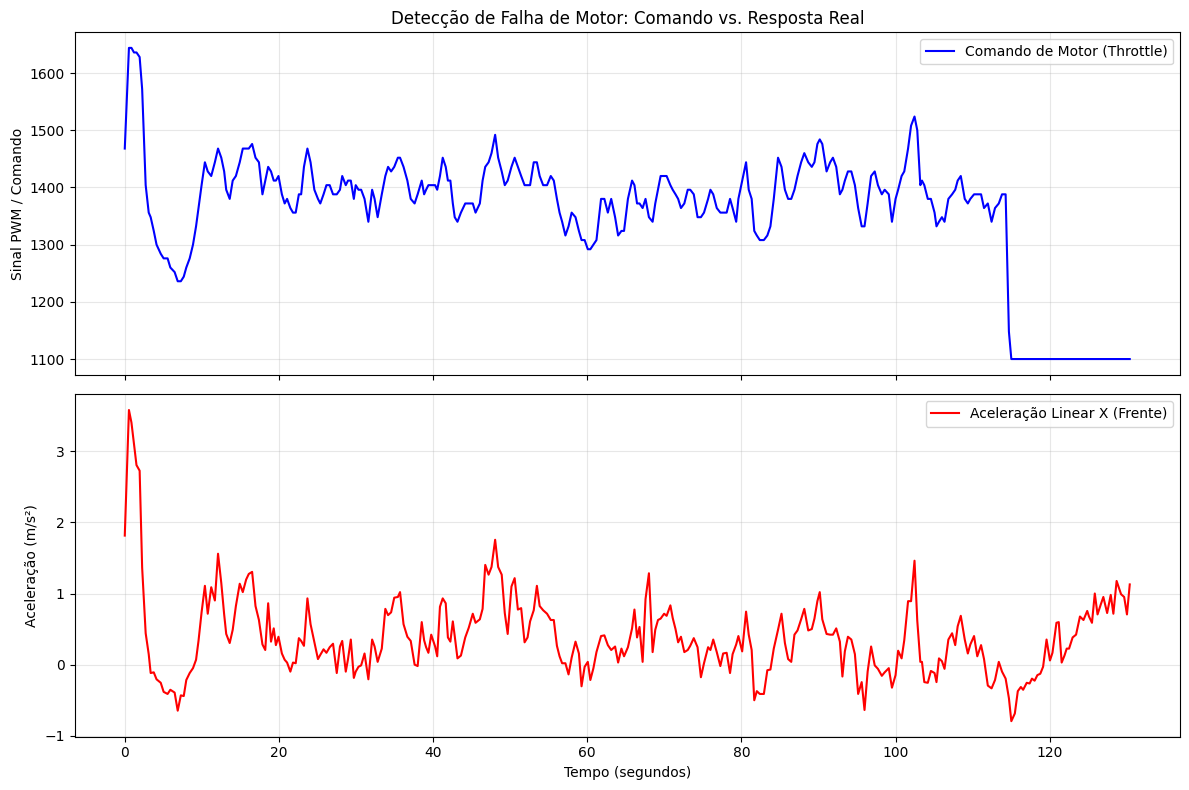

In [9]:
import matplotlib.pyplot as plt

def plot_engine_failure(df):
    # Criando a figura com dois subplots (um para o comando e outro para a resposta)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Normalizando o tempo para segundos (começando do zero)
    time_s = (df['%time'] - df['%time'].iloc[0]) / 1e9

    # Subplot 1: Comando de Motor (Throttle)
    ax1.plot(time_s, df['field.channels2'], color='blue', label='Comando de Motor (Throttle)')
    ax1.set_ylabel('Sinal PWM / Comando')
    ax1.set_title('Detecção de Falha de Motor: Comando vs. Resposta Real')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Subplot 2: Aceleração Frontal (Onde a falha aparece)
    ax2.plot(time_s, df['field.linear_acceleration.x'], color='red', label='Aceleração Linear X (Frente)')
    ax2.set_ylabel('Aceleração (m/s²)')
    ax2.set_xlabel('Tempo (segundos)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Rodar a visualização
plot_engine_failure(df)

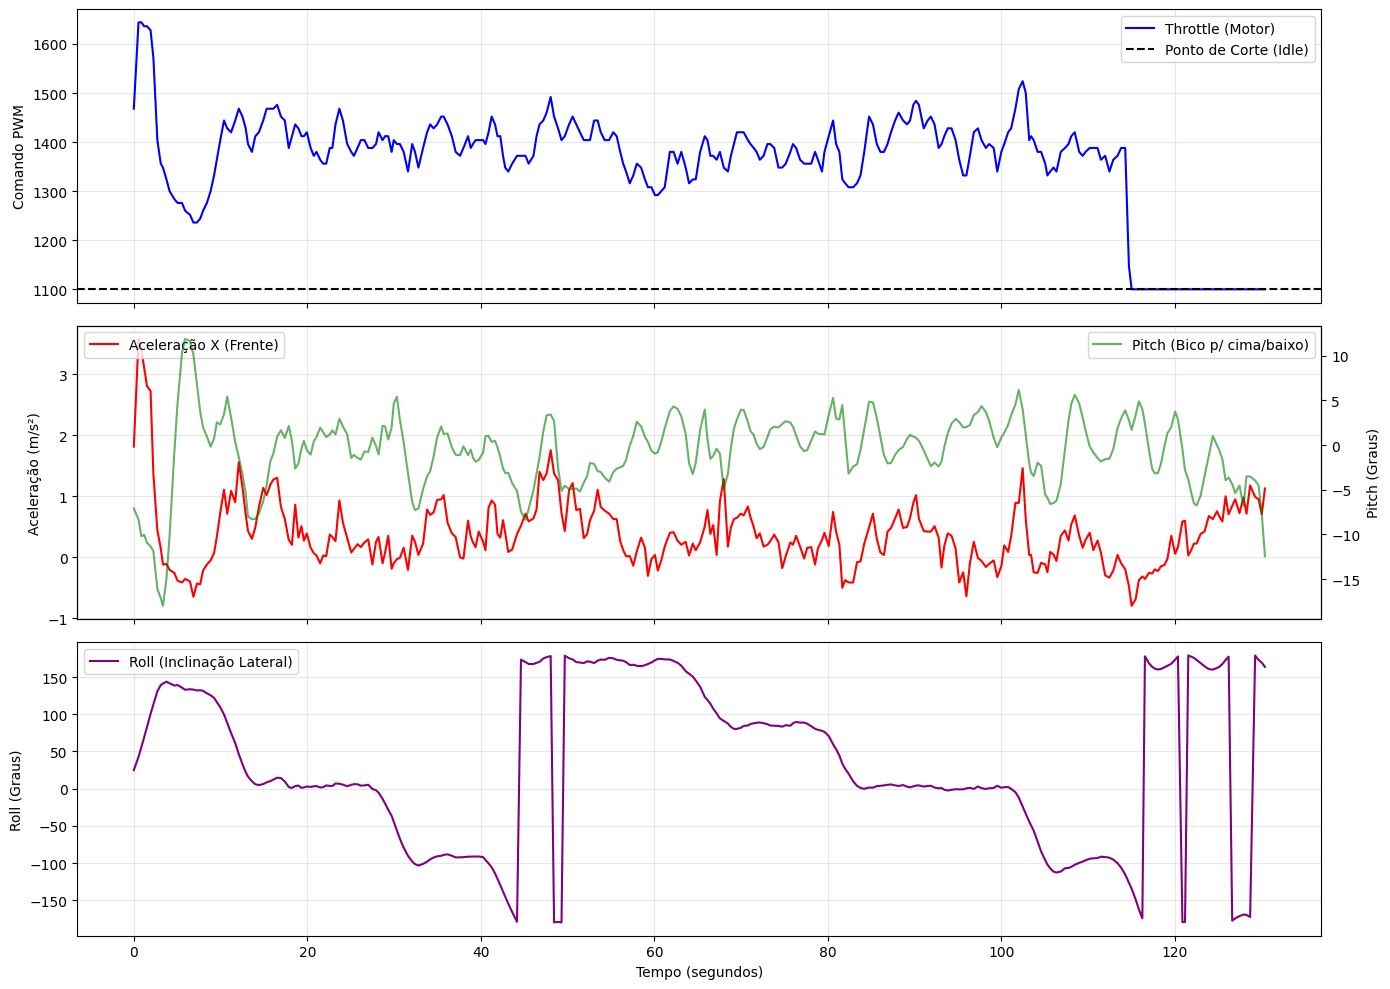

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# 1. Carregar e Sincronizar 
# Vamos converter os quatérnios da IMU para Graus
def get_euler_angles(df):
    # Extrai os quatérnios
    quats = df[['field.orientation.x', 'field.orientation.y', 'field.orientation.z', 'field.orientation.w']].values
    # Converte para ângulos de Euler (em graus)
    rotation = R.from_quat(quats)
    euler = rotation.as_euler('xyz', degrees=True)
    df['pitch_deg'] = euler[:, 1]
    df['roll_deg'] = euler[:, 2]
    return df

df = get_euler_angles(df)

# 2. Visualização Profissional
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
time_s = (df['%time'] - df['%time'].iloc[0]) / 1e9

# Subplot 1: Comando de Motor
ax1.plot(time_s, df['field.channels2'], color='blue', label='Throttle (Motor)')
ax1.axhline(y=1100, color='black', linestyle='--', label='Ponto de Corte (Idle)')
ax1.set_ylabel('Comando PWM')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Subplot 2: Aceleração vs Pitch (A explicação física)
ax2.plot(time_s, df['field.linear_acceleration.x'], color='red', label='Aceleração X (Frente)')
ax2_twin = ax2.twinx() # Escala separada para o Pitch
ax2_twin.plot(time_s, df['pitch_deg'], color='green', label='Pitch (Bico p/ cima/baixo)', alpha=0.6)
ax2.set_ylabel('Aceleração (m/s²)')
ax2_twin.set_ylabel('Pitch (Graus)')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Subplot 3: Instabilidade Lateral (Roll)
ax3.plot(time_s, df['roll_deg'], color='purple', label='Roll (Inclinação Lateral)')
ax3.set_ylabel('Roll (Graus)')
ax3.set_xlabel('Tempo (segundos)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

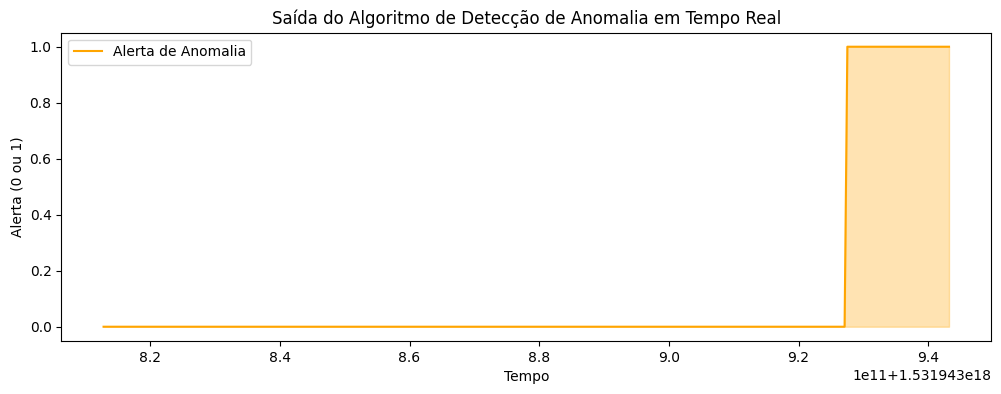

In [11]:
def detect_engine_failure_anomaly(df):
    # 1. Calculamos a variabilidade do Roll (instabilidade lateral)
    # Janela de 1 segundo (se a frequência for 50Hz, usar window=50)
    df['roll_std'] = df['roll_deg'].rolling(window=20).std()
    
    # 2. Definimos as condições da falha
    # Condição A: Motor cortado (PWM próximo de 1100)
    cond_motor = df['field.channels2'] <= 1150
    
    # Condição B: Instabilidade de Roll (desvio padrão alto)
    cond_roll = df['roll_std'] > 5 # Mais de 5 graus de oscilação
    
    # Condição C: Tendência de queda no Pitch
    cond_pitch = df['pitch_deg'] < -5
    
    # 3. Alerta Combinado
    df['anomaly_alert'] = np.where(cond_motor & (cond_roll | cond_pitch), 1, 0)
    
    return df

df = detect_engine_failure_anomaly(df)

# Plotando o resultado da detecção
plt.figure(figsize=(12,4))
plt.plot(df['%time'], df['anomaly_alert'], color='orange', label='Alerta de Anomalia')
plt.fill_between(df['%time'], 0, df['anomaly_alert'], color='orange', alpha=0.3)
plt.title("Saída do Algoritmo de Detecção de Anomalia em Tempo Real")
plt.xlabel("Tempo")
plt.ylabel("Alerta (0 ou 1)")
plt.legend()
plt.show()

In [12]:
# Encontrando o exato momento em que o comando de motor cai para o valor de falha
# Vamos considerar 1100 como o valor de corte
tempo_da_falha = df_rc[df_rc['field.channels2'] <= 1101]['%time'].min()

print(f"A falha foi injetada no timestamp: {tempo_da_falha}")

A falha foi injetada no timestamp: 1531943927688233537


In [21]:
cinco_segundos_em_ns = 5 * 1e9

t_corte_treino = tempo_da_falha - cinco_segundos_em_ns

# Dataset de Treino: Apenas o que é 100% garantido como saudável
df_treino = df[df['%time'] < t_corte_treino]

# Dataset de Teste: Começa um pouco antes da falha para vermos o modelo funcionando 
# no normal e depois disparando na anomalia
df_teste = df[df['%time'] >= t_corte_treino]

print(f"Linhas para treino: {len(df_treino)}")
print(f"Linhas para teste: {len(df_teste)}")

Linhas para treino: 252
Linhas para teste: 51


In [22]:
# Criando o Ground Truth: 0 para normal, 1 para falha
df['ground_truth'] = (df['%time'] >= tempo_da_falha).astype(int)

In [23]:
df

,%time,field.linear_acceleration.x,field.angular_velocity.x,field.angular_velocity.y,field.angular_velocity.z,field.orientation.x,field.orientation.y,field.orientation.z,field.orientation.w,field.channels2,accel_delta,vibration_intensity,engine_efficiency,throttle_prev,pitch_deg,roll_deg,roll_std,anomaly_alert,ground_truth,roll_rate_prev
25,1531943820793614620,-0.215746,0.082621,-0.060920,-0.063676,-0.010031,-0.064403,-0.909755,-0.409998,1260,0.225553,0.120797,-0.000171,1260.0,1.980434,131.605544,31.053388,0,0,0.114319
26,1531943821233863517,-0.117680,0.165507,-0.085392,-0.124968,-0.035961,-0.093063,-0.894863,-0.435047,1276,0.098067,0.224280,-0.000092,1252.0,0.951946,128.240709,25.453595,0,0,0.082621
27,1531943821663172780,-0.049033,0.091908,-0.027924,-0.068666,-0.069333,-0.131678,-0.879777,-0.451493,1300,0.068647,0.118076,-0.000038,1236.0,-0.177192,125.640477,19.958793,0,0,0.165507
28,1531943822059054206,0.068647,0.190954,0.008891,-0.263003,-0.078861,-0.155485,-0.861065,-0.477674,1332,0.117680,0.325135,0.000051,1236.0,0.729626,122.090650,14.891387,0,0,0.091908
29,1531943822376901254,0.333426,0.611613,-0.079148,-0.308182,-0.109862,-0.218550,-0.821868,-0.514488,1364,0.264780,0.689428,0.000244,1244.0,2.538942,116.545136,10.724430,0,0,0.190954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,1531943941491996642,1.176798,0.053843,-0.234794,-0.195660,-0.025433,-0.081257,-0.994152,0.066418,1100,0.460913,0.310339,0.001069,1100.0,-3.517971,-172.636302,167.950262,1,1,0.229043
324,1531943942067681887,0.990472,0.036893,-0.056033,-0.316570,-0.035190,-0.093619,-0.994974,-0.004850,1100,-0.186326,0.323601,0.000900,1100.0,-3.963370,179.067238,161.240647,1,1,0.053843
325,1531943942472051935,0.951245,0.146542,-0.159355,-0.158169,-0.046766,-0.120761,-0.990011,-0.055751,1100,-0.039227,0.268116,0.000864,1100.0,-4.538691,172.988629,161.020145,1,1,0.036893
326,1531943942834921809,0.706079,0.036797,-0.132573,-0.143827,-0.076616,-0.102990,-0.988213,-0.083416,1100,-0.245166,0.199037,0.000641,1100.0,-7.714883,169.496449,160.746084,1,1,0.146542


In [26]:
features = ['field.channels2', 'pitch_deg', 'roll_deg', 'roll_rate_prev']
target = 'field.linear_acceleration.x'

# Treino
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(df_treino[features], df_treino[target])

# --- DETECÇÃO E 3 SIGMAS ---

# Erro no treino para definir o limiar (baseline de erro "normal")
preds_treino = model.predict(df_treino[features])
erros_treino = np.abs(df_treino[target] - preds_treino)
limiar = erros_treino.mean() + (3 * erros_treino.std())

# Predição no teste
preds_teste = model.predict(df_teste[features])
erro_teste = np.abs(df_teste[target] - preds_teste)

# O Gatilho de Anomalia
df_teste['pred_anomalia'] = (erro_teste > limiar).astype(int)

# --- VALIDAÇÃO FINAL ---
print("Relatório de Performance do Detector:")
print(classification_report(df_teste['ground_truth'], df_teste['pred_anomalia']))

Relatório de Performance do Detector:
              precision    recall  f1-score   support

           0       0.33      0.64      0.44        11
           1       0.87      0.65      0.74        40

    accuracy                           0.65        51
   macro avg       0.60      0.64      0.59        51
weighted avg       0.75      0.65      0.68        51

